# 原始拉曼光谱查看器（ramanv2）

设置 `SAMPLE_PATH` 可指定一条谱；保持为 `None` 时会按固定种子从文件夹中抽样。


读取光谱：dataset/alldata/init/Klebsiella/KP02/cell18_Area01_000_shift_cos.arc_data


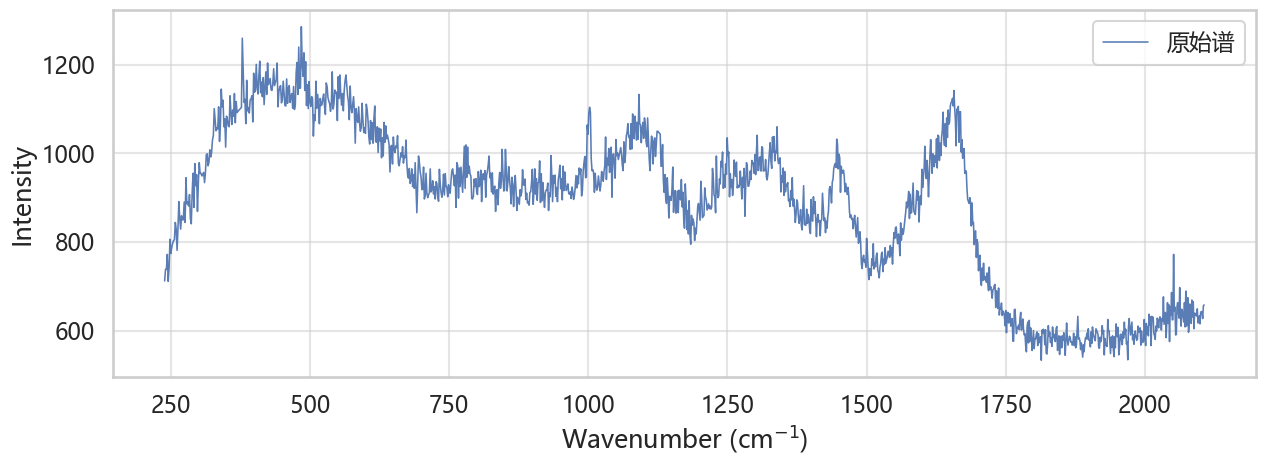

In [7]:
from pathlib import Path
import random
import sys

import matplotlib.pyplot as plt
from matplotlib import font_manager
import seaborn as sns


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / 'ramanv2').is_dir() and (candidate / 'dataset').is_dir():
            return candidate
    raise FileNotFoundError('未找到同时包含 ramanv2 和 dataset 的项目根目录。')


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from ramanv2.data.io import read_arc_data

# 手动指定时，填入相对项目根目录或绝对路径；例如：
# SAMPLE_PATH = 'dataset/50种菌cos/init/属名/文件夹名/某条谱.arc_data'
SAMPLE_PATH = None

# SAMPLE_PATH 为 None 时，从该目录随机抽取一条谱。
SAMPLE_FOLDER = PROJECT_ROOT / 'dataset' / 'alldata' / 'init'
SAMPLE_SEED = 46

# 设为数值可放大指定波数区间；保持 None 则显示全谱。
DISPLAY_MIN = None
DISPLAY_MAX = None


for font_name, font_path in (
    ('Microsoft YaHei', Path('C:/Windows/Fonts/msyh.ttc')),
    ('SimHei', Path('C:/Windows/Fonts/simhei.ttf')),
):
    if font_path.is_file():
        font_manager.fontManager.addfont(str(font_path))

available_fonts = {font.name for font in font_manager.fontManager.ttflist}
chinese_font = next((name for name in ('Microsoft YaHei', 'SimHei') if name in available_fonts), None)
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['axes.unicode_minus'] = False
if chinese_font:
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = [chinese_font, 'DejaVu Sans']


if SAMPLE_PATH is not None:
    spectrum_path = Path(SAMPLE_PATH)
    if not spectrum_path.is_absolute():
        spectrum_path = PROJECT_ROOT / spectrum_path
else:
    sample_folder = Path(SAMPLE_FOLDER)
    if not sample_folder.is_absolute():
        sample_folder = PROJECT_ROOT / sample_folder
    candidates = sorted(sample_folder.rglob('*.arc_data'))
    if not candidates:
        raise FileNotFoundError(f'未找到 .arc_data 文件：{sample_folder}')
    spectrum_path = random.Random(SAMPLE_SEED).choice(candidates)

wn, intensity = read_arc_data(spectrum_path)
if wn.size == 0 or intensity.size == 0:
    raise ValueError(f'无法读取光谱：{spectrum_path}')

try:
    display_path = spectrum_path.relative_to(PROJECT_ROOT).as_posix()
except ValueError:
    display_path = str(spectrum_path)
print(f'读取光谱：{display_path}')

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(wn, intensity, color='#4C72B0', linewidth=1.15, alpha=0.92, label='原始谱')
ax.set_xlabel('Wavenumber (cm$^{-1}$)')
ax.set_ylabel('Intensity')
if DISPLAY_MIN is not None and DISPLAY_MAX is not None:
    ax.set_xlim(DISPLAY_MIN, DISPLAY_MAX)
ax.legend(loc='best')
fig.tight_layout()
plt.show()
